## Analysis of Airbnb Data – New York City


In [68]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Data Loading

In [123]:
df = pd.read_csv("AB_NYC_2019.csv")
df

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48890,36484665,Charming one bedroom - newly renovated rowhouse,8232441,Sabrina,Brooklyn,Bedford-Stuyvesant,40.67853,-73.94995,Private room,70,2,0,NaN,NaN,2,9
48891,36485057,Affordable room in Bushwick/East Williamsburg,6570630,Marisol,Brooklyn,Bushwick,40.70184,-73.93317,Private room,40,4,0,NaN,NaN,2,36
48892,36485431,Sunny Studio at Historical Neighborhood,23492952,Ilgar & Aysel,Manhattan,Harlem,40.81475,-73.94867,Entire home/apt,115,10,0,NaN,NaN,1,27
48893,36485609,43rd St. Time Square-cozy single bed,30985759,Taz,Manhattan,Hell's Kitchen,40.75751,-73.99112,Shared room,55,1,0,NaN,NaN,6,2


In [124]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [125]:
df.columns

Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365'],
      dtype='object')

In [126]:
df.shape

(48895, 16)

In [127]:
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [128]:
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


In [129]:
df.describe(include="object")

,name,host_name,neighbourhood_group,neighbourhood,room_type,last_review
count,48879,48874,48895,48895,48895,38843
unique,47905,11452,5,221,3,1764
top,Hillside Hotel,Michael,Manhattan,Williamsburg,Entire home/apt,2019-06-23
freq,18,417,21661,3920,25409,1413


In [130]:
df.isnull().sum()

id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

### Data Observation:

> The dataset contains 48,895 Airbnb listings across New York City with 16 features. It includes information about listing location,
room type, price, minimum stay, reviews, host listings and availability. The price variable will be used as the primary outcome 
for exploratory analysis, while location, room type, reviews and availability will be examined to identify factors and patterns associated 
with listing prices.

### Data cleaning

In [131]:
## checking duplicates
df.duplicated().sum()

np.int64(0)

In [132]:

## checking missing values
df.isnull().sum()

id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

In [133]:
## fixing null values in reviews_per_month
df['reviews_per_month'].describe()

count    38843.000000
mean         1.373221
std          1.680442
min          0.010000
25%          0.190000
50%          0.720000
75%          2.020000
max         58.500000
Name: reviews_per_month, dtype: float64

In [134]:
df['reviews_per_month'] = df['reviews_per_month'].fillna(0)

In [135]:
df['reviews_per_month'].isnull().sum()

np.int64(0)

In [136]:
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,0.00,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [137]:
df['last_review'] = pd.to_datetime(df['last_review'])

In [158]:
df['last_review'].isnull().sum()

np.int64(10052)

**Missing Value Treatment**: The last_review column contains 10,052 missing values. 
These values were retained as NaT because they indicate that no review date was recorded. 
Removing these records would unnecessarily reduce the dataset,
while filling them with an artificial date could lead to misleading analysis.

### Missing Value Treatment

- `name`: Missing values were replaced with "Unknown".
- `host_name`: Missing values were replaced with "Unknown".
- `reviews_per_month`: Missing values were replaced with 0 because these listings have no recorded monthly reviews.
- `last_review`: Missing values were retained because no valid review date was available.

In [159]:
df.dtypes

id                                         int64
name                                      object
host_id                                    int64
host_name                                 object
neighbourhood_group                       object
neighbourhood                             object
latitude                                 float64
longitude                                float64
room_type                                 object
price                                      int64
minimum_nights                             int64
number_of_reviews                          int64
last_review                       datetime64[ns]
reviews_per_month                        float64
calculated_host_listings_count             int64
availability_365                           int64
dtype: object

In [160]:
df['last_review'].describe()

count                            38843
mean     2018-10-04 01:47:23.910099456
min                2011-03-28 00:00:00
25%                2018-07-08 00:00:00
50%                2019-05-19 00:00:00
75%                2019-06-23 00:00:00
max                2019-07-08 00:00:00
Name: last_review, dtype: object

In [161]:
df['last_review'].isnull().sum()

np.int64(10052)

In [162]:
df['last_review'] = pd.to_datetime(df['last_review'])

In [163]:
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaT,0.00,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [164]:
df.isnull().sum()

id                                    0
name                                  0
host_id                               0
host_name                             0
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                     0
calculated_host_listings_count        0
availability_365                      0
dtype: int64

In [165]:
### for categorical data
df['host_name'].isnull().sum()

np.int64(0)

In [166]:
df['host_name'].fillna('Unknown',inplace=True)

C:\Users\snigd\AppData\Local\Temp\ipykernel_1884\1968008729.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['host_name'].fillna('Unknown',inplace=True)


In [167]:
df['host_name'].isnull().sum()

np.int64(0)

In [168]:
## missing values for name
df['name'].isnull().sum()

np.int64(0)

In [169]:
df['name'].fillna('Unknown', inplace=True)

C:\Users\snigd\AppData\Local\Temp\ipykernel_1884\4270368798.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['name'].fillna('Unknown', inplace=True)


In [170]:
df.isnull().sum()

id                                    0
name                                  0
host_id                               0
host_name                             0
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                     0
calculated_host_listings_count        0
availability_365                      0
dtype: int64

In [171]:

df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaT,0.00,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [152]:
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843,48895.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,2018-10-04 01:47:23.910099456,1.090910,7.143982,112.781327
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,2011-03-28 00:00:00,0.000000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,2018-07-08 00:00:00,0.040000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,2019-05-19 00:00:00,0.370000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2019-06-23 00:00:00,1.580000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,2019-07-08 00:00:00,58.500000,327.000000,365.000000
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,NaN,1.597283,32.952519,131.622289


In [153]:
df.columns

Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365'],
      dtype='object')

In [154]:
df['room_type'].unique()

array(['Private room', 'Entire home/apt', 'Shared room'], dtype=object)

In [155]:
df['room_type'].value_counts()

room_type
Entire home/apt    25409
Private room       22326
Shared room         1160
Name: count, dtype: int64

In [156]:
df['neighbourhood_group'].unique()

array(['Brooklyn', 'Manhattan', 'Queens', 'Staten Island', 'Bronx'],
      dtype=object)

In [157]:
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaT,0.00,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


#### Data Observation:
- 1.The dataset contains Airbnb listings from New York City.
- 2.The dataset contains information about listing location, room type, price, minimum nights, reviews, and availability.
- 3.price, minimum_nights, number_of_reviews, and availability_365 are numerical variables.
- 4.neighbourhood_group, neighbourhood, and room_type are categorical variables.
- 5.last_review contains date information and should be converted from object to datetime.
- 6.Missing values were found mainly in last_review and reviews_per_month.
- 7.reviews_per_month contains missing values that can be treated as 0 where appropriate, representing no recorded review activity.
- 8.Missing last_review values were retained as NaT because the absence of a review date can itself provide information.
- 9.id was removed because it is only a unique identifier and does not contribute to the analysis.
- 10.host_name was removed because individual host names are not required for the planned analysis.
- 11.room_type contains three main categories: Private room, Entire home/apt, and Shared room.
- 12.Duplicate records and unusual numerical values should be checked before starting the analysis.

## Outlier Detection and Treatment

Outliers were analyzed for important numerical variables such as price,
minimum nights, and availability using the Interquartile Range (IQR) method.

In [172]:
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Q1: 69.0
Q3: 175.0
IQR: 106.0
Lower Bound: -90.0
Upper Bound: 334.0


In [173]:
price_outliers = df[
    (df['price'] < lower_bound) |
    (df['price'] > upper_bound)
]

print("Number of price outliers:", len(price_outliers))

Number of price outliers: 2972


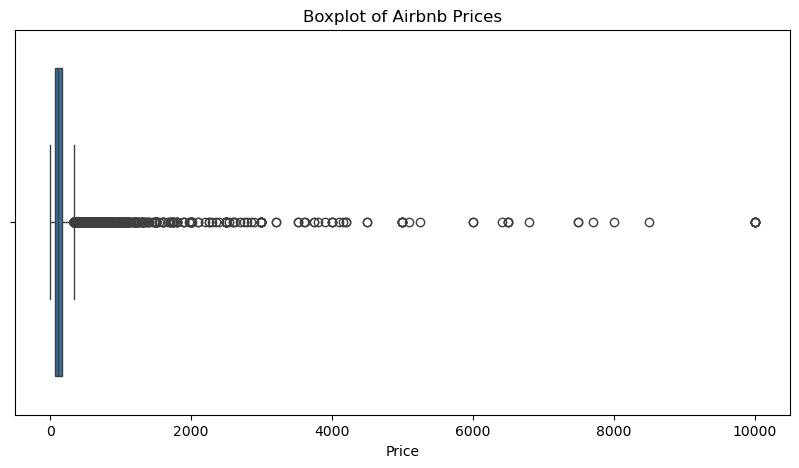

In [174]:
plt.figure(figsize=(10,5))

sns.boxplot(x=df['price'])

plt.title('Boxplot of Airbnb Prices')
plt.xlabel('Price')

plt.show()

**Observation**:
The boxplot shows that Airbnb prices contain several high-value observations. 
The distribution is strongly right-skewed, indicating the presence of expensive listings.

In [190]:
# Create a filtered dataset for analysis without extreme price outliers
df_price_clean = df[
    (df['price'] >= lower_bound) &
    (df['price'] <= upper_bound)
].copy()

print("Original dataset shape:", df.shape)
print("Dataset shape after removing price outliers:", df_price_clean.shape)

Original dataset shape: (48895, 16)
Dataset shape after removing price outliers: (45923, 16)


In [191]:
zero_price = (df['price'] == 0).sum()

print("Number of zero-price listings:", zero_price)


Number of zero-price listings: 11


In [192]:
df_price_clean = df[
    (df['price'] > 0) &
    (df['price'] <= upper_bound)
].copy()

print("Original dataset shape:", df.shape)
print("Cleaned price dataset shape:", df_price_clean.shape)

Original dataset shape: (48895, 16)
Cleaned price dataset shape: (45912, 16)


### Data Visualization

### Univariate analysis

In [37]:
df['neighbourhood_group'].value_counts()

neighbourhood_group
Manhattan        21661
Brooklyn         20104
Queens            5666
Bronx             1091
Staten Island      373
Name: count, dtype: int64

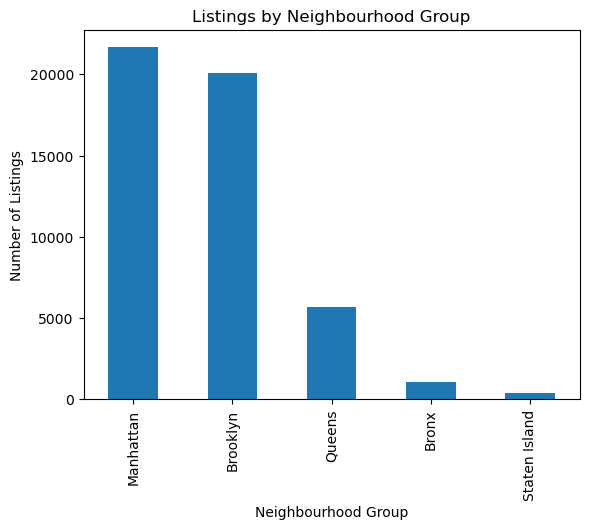

In [38]:
df['neighbourhood_group'].value_counts().plot(kind='bar')
plt.title('Listings by Neighbourhood Group')
plt.xlabel('Neighbourhood Group')
plt.ylabel('Number of Listings')
plt.show()

In [39]:
df['neighbourhood'].value_counts()

neighbourhood
Williamsburg          3920
Bedford-Stuyvesant    3714
Harlem                2658
Bushwick              2465
Upper West Side       1971
                      ... 
Fort Wadsworth           1
Richmondtown             1
New Dorp                 1
Rossville                1
Willowbrook              1
Name: count, Length: 221, dtype: int64

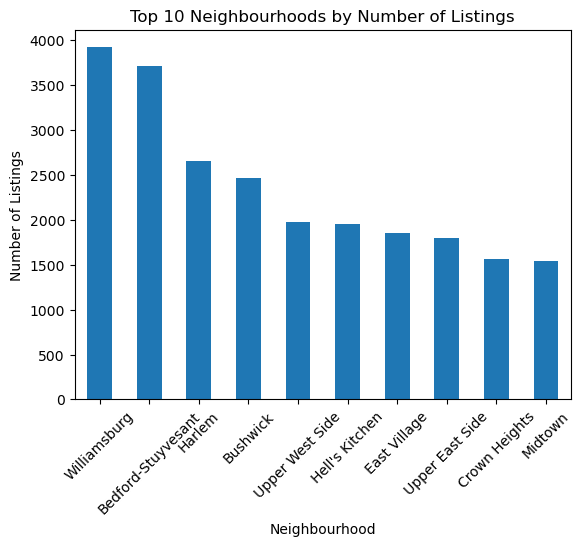

In [40]:
df['neighbourhood'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 Neighbourhoods by Number of Listings')
plt.xlabel('Neighbourhood')
plt.ylabel('Number of Listings')
plt.xticks(rotation=45)
plt.show()

In [41]:
df['room_type'].value_counts()

room_type
Entire home/apt    25409
Private room       22326
Shared room         1160
Name: count, dtype: int64

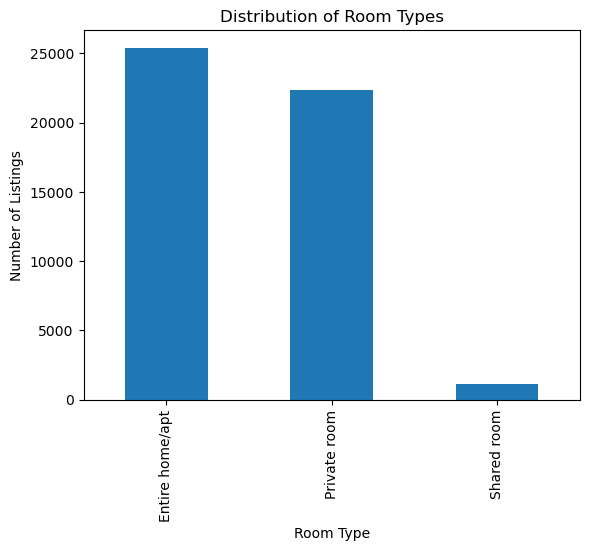

In [42]:
df['room_type'].value_counts().plot(kind='bar')
plt.title('Distribution of Room Types')
plt.xlabel('Room Type')
plt.ylabel('Number of Listings')
plt.show()

In [43]:
df['price'].describe()

count    48895.000000
mean       152.720687
std        240.154170
min          0.000000
25%         69.000000
50%        106.000000
75%        175.000000
max      10000.000000
Name: price, dtype: float64

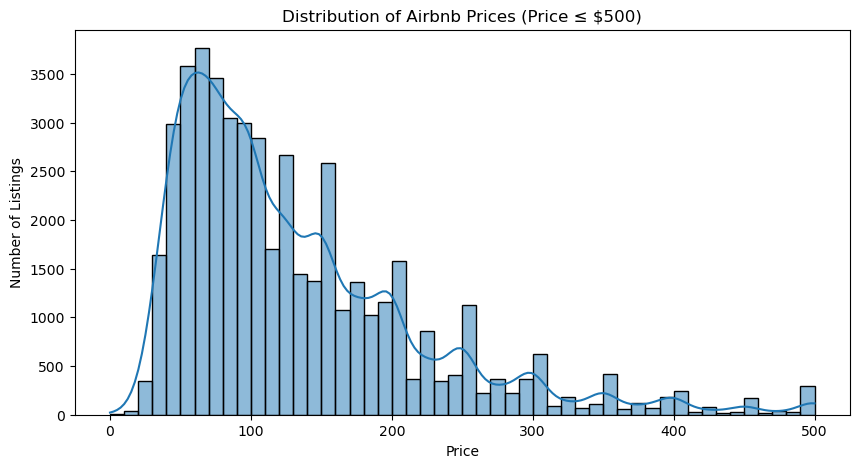

In [177]:
plt.figure(figsize=(10,5))

sns.histplot(
    df[df['price'] <= 500]['price'],
    bins=50,
    kde=True
)

plt.title('Distribution of Airbnb Prices (Price ≤ $500)')
plt.xlabel('Price')
plt.ylabel('Number of Listings')

plt.show()

In [45]:
df['number_of_reviews'].describe()

count    48895.000000
mean        23.274466
std         44.550582
min          0.000000
25%          1.000000
50%          5.000000
75%         24.000000
max        629.000000
Name: number_of_reviews, dtype: float64

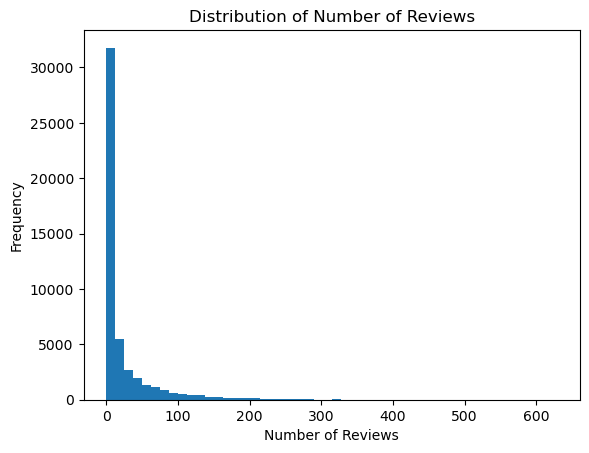

In [46]:
df['number_of_reviews'].plot(kind='hist', bins=50)
plt.title('Distribution of Number of Reviews')
plt.xlabel('Number of Reviews')
plt.ylabel('Frequency')
plt.show()

In [47]:
df['minimum_nights'].describe()

count    48895.000000
mean         7.029962
std         20.510550
min          1.000000
25%          1.000000
50%          3.000000
75%          5.000000
max       1250.000000
Name: minimum_nights, dtype: float64

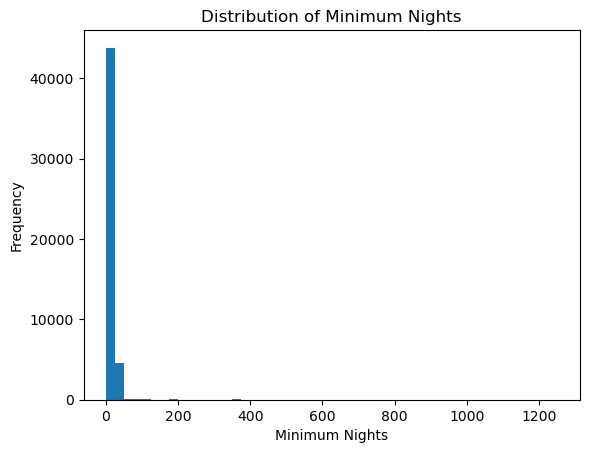

In [48]:
df['minimum_nights'].plot(kind='hist', bins=50)
plt.title('Distribution of Minimum Nights')
plt.xlabel('Minimum Nights')
plt.ylabel('Frequency')
plt.show()

In [49]:
df['availability_365'].describe()

count    48895.000000
mean       112.781327
std        131.622289
min          0.000000
25%          0.000000
50%         45.000000
75%        227.000000
max        365.000000
Name: availability_365, dtype: float64

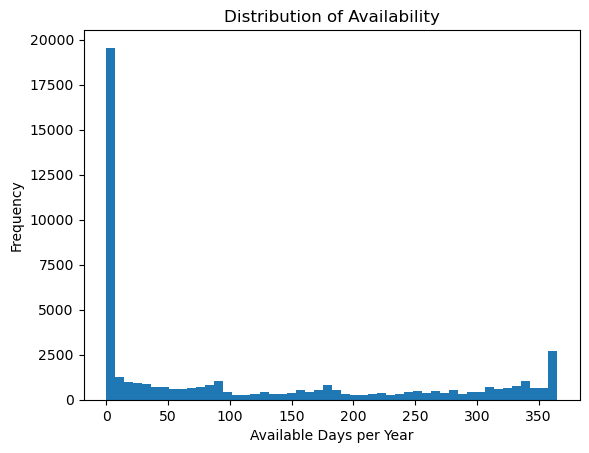

In [50]:
df['availability_365'].plot(kind='hist', bins=50)
plt.title('Distribution of Availability')
plt.xlabel('Available Days per Year')
plt.ylabel('Frequency')
plt.show()

**Observation**:The Airbnb dataset shows a concentration of listings in particular room types and neighbourhood groups. Numerical variables such as price, minimum nights, and reviews show skewed distributions and potential outliers.

### Bivariate analysis

In [182]:
df.groupby('room_type')['price'].agg(
    ['count', 'mean', 'median']
)

,count,mean,median
room_type,,,
Entire home/apt,25409,211.794246,160.0
Private room,22326,89.780973,70.0
Shared room,1160,70.127586,45.0


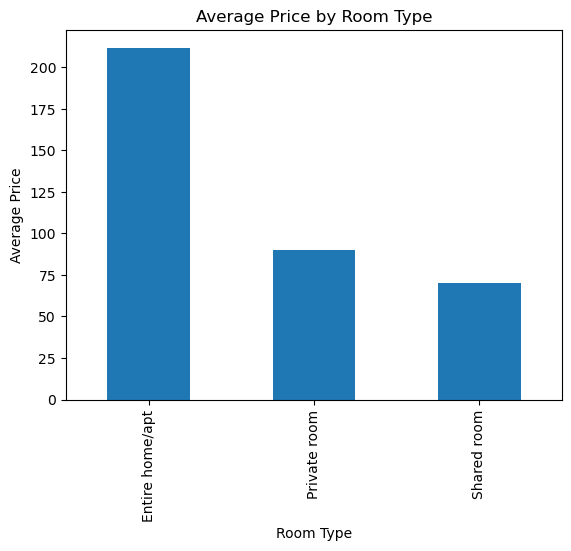

In [183]:
df.groupby('room_type')['price'].mean().plot(kind='bar')
plt.title('Average Price by Room Type')
plt.xlabel('Room Type')
plt.ylabel('Average Price')
plt.show()

**Observation**: Entire homes/apartments have the highest average and median prices, while shared rooms have the lowest typical prices.

In [184]:
df.groupby('neighbourhood_group')['price'].agg(
    ['count', 'mean', 'median']
).sort_values('mean', ascending=False)


,count,mean,median
neighbourhood_group,,,
Manhattan,21661,196.875814,150.0
Brooklyn,20104,124.383207,90.0
Staten Island,373,114.812332,75.0
Queens,5666,99.517649,75.0
Bronx,1091,87.496792,65.0


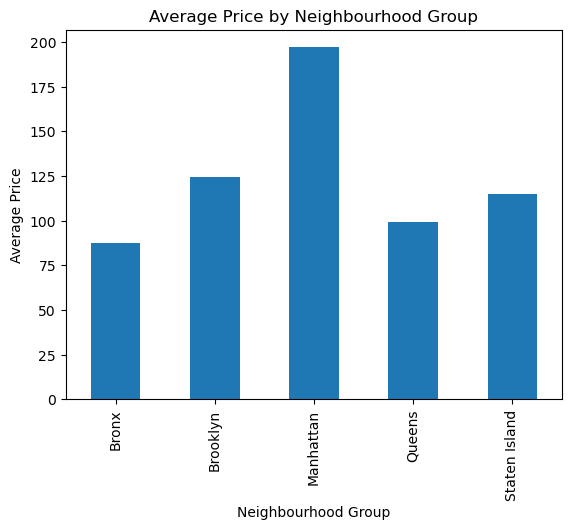

In [185]:
df.groupby('neighbourhood_group')['price'].mean().plot(kind='bar')
plt.title('Average Price by Neighbourhood Group')
plt.xlabel('Neighbourhood Group')
plt.ylabel('Average Price')
plt.show()

**Neighbourhood group
Observation**: Manhattan and Brooklyn contain the largest number of Airbnb listings, while Staten Island has substantially fewer listings.

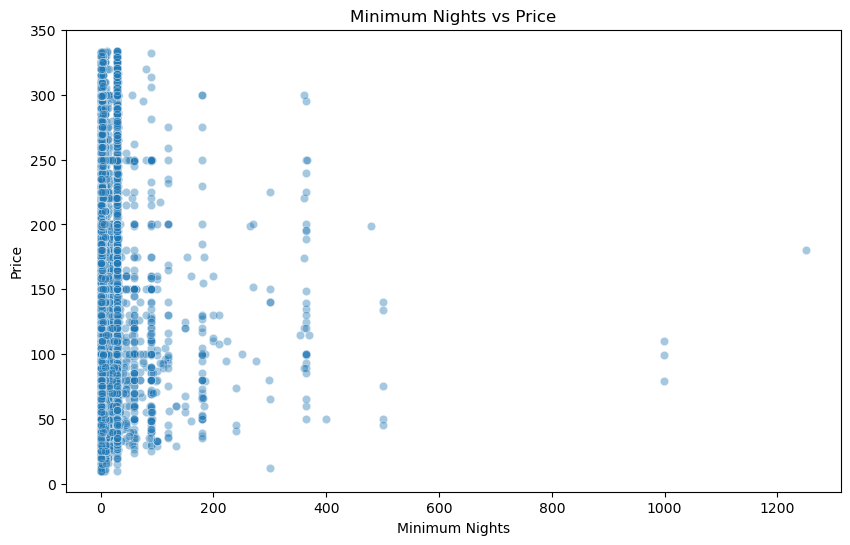

In [193]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_price_clean,
    x='minimum_nights',
    y='price',
    alpha=0.4
)

plt.title('Minimum Nights vs Price')
plt.xlabel('Minimum Nights')
plt.ylabel('Price')

plt.show()

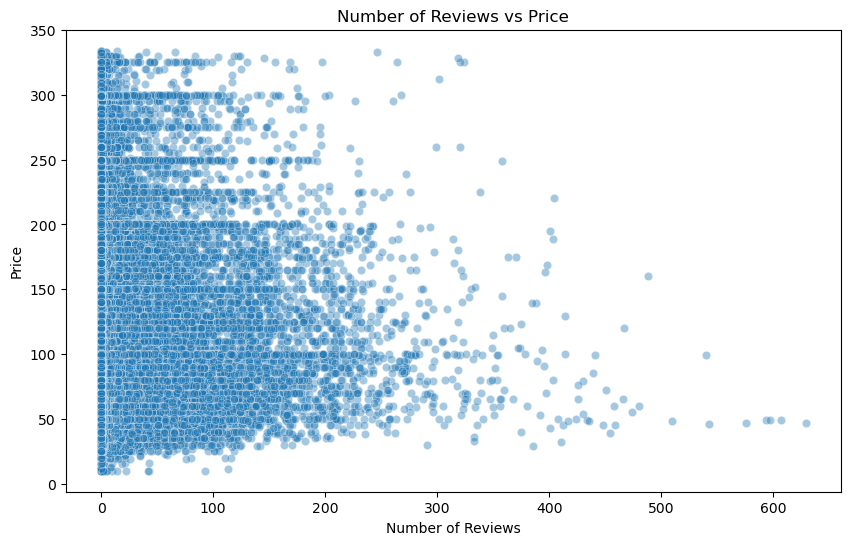

In [194]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_price_clean,
    x='number_of_reviews',
    y='price',
    alpha=0.4
)

plt.title('Number of Reviews vs Price')
plt.xlabel('Number of Reviews')
plt.ylabel('Price')

plt.show()

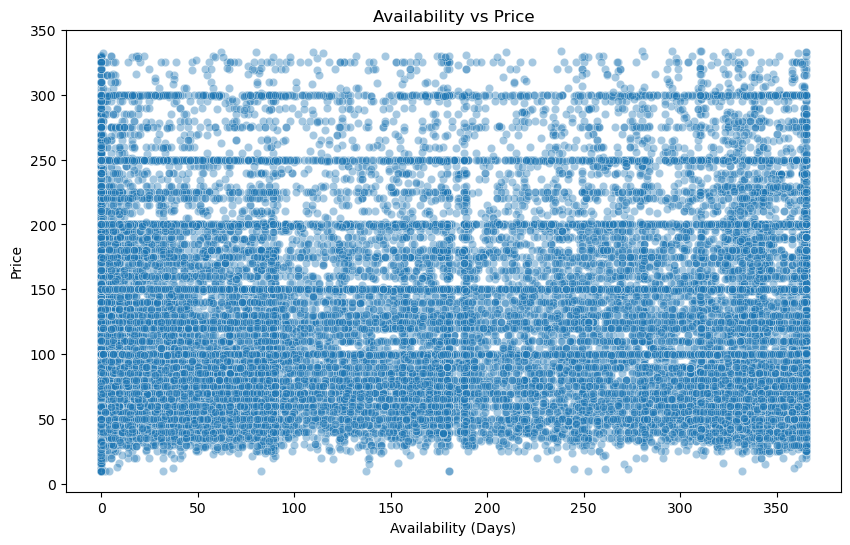

In [199]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_price_clean,
    x='availability_365',
    y='price',
    alpha=0.4
)

plt.title('Availability vs Price')
plt.xlabel('Availability (Days)')
plt.ylabel('Price')

plt.show()

**Observation:** The scatter plot shows that listings are distributed across different levels of annual availability and price. There is no clear strong linear relationship between availability and price.

### Multivariate analysis

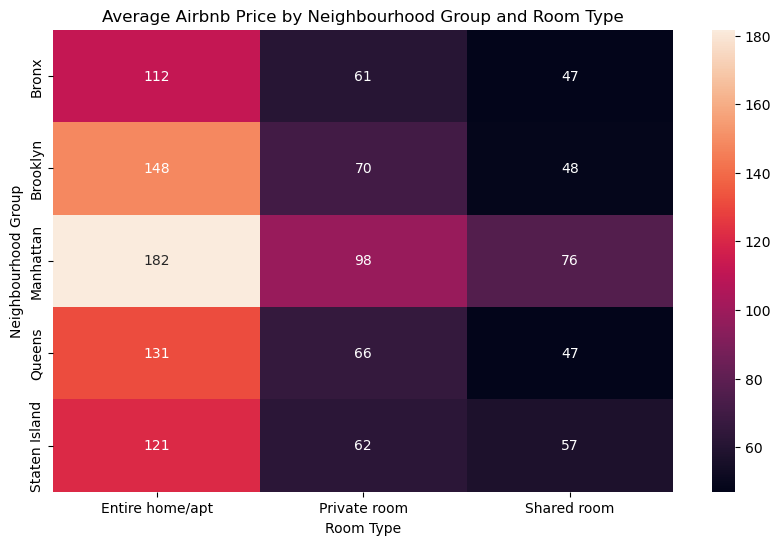

In [200]:
# Multivariate Analysis 1
# Average Price by Neighbourhood Group and Room Type

pivot_price = pd.pivot_table(
    df_price_clean,
    values='price',
    index='neighbourhood_group',
    columns='room_type',
    aggfunc='mean'
)

plt.figure(figsize=(10, 6))

sns.heatmap(
    pivot_price,
    annot=True,
    fmt='.0f'
)

plt.title('Average Airbnb Price by Neighbourhood Group and Room Type')
plt.xlabel('Room Type')
plt.ylabel('Neighbourhood Group')

plt.show()

**Observation:** The heatmap shows how average Airbnb prices vary across neighbourhood groups and room types. Entire home/apartment listings generally have higher average prices than private and shared rooms, while average prices also vary across neighbourhood groups.

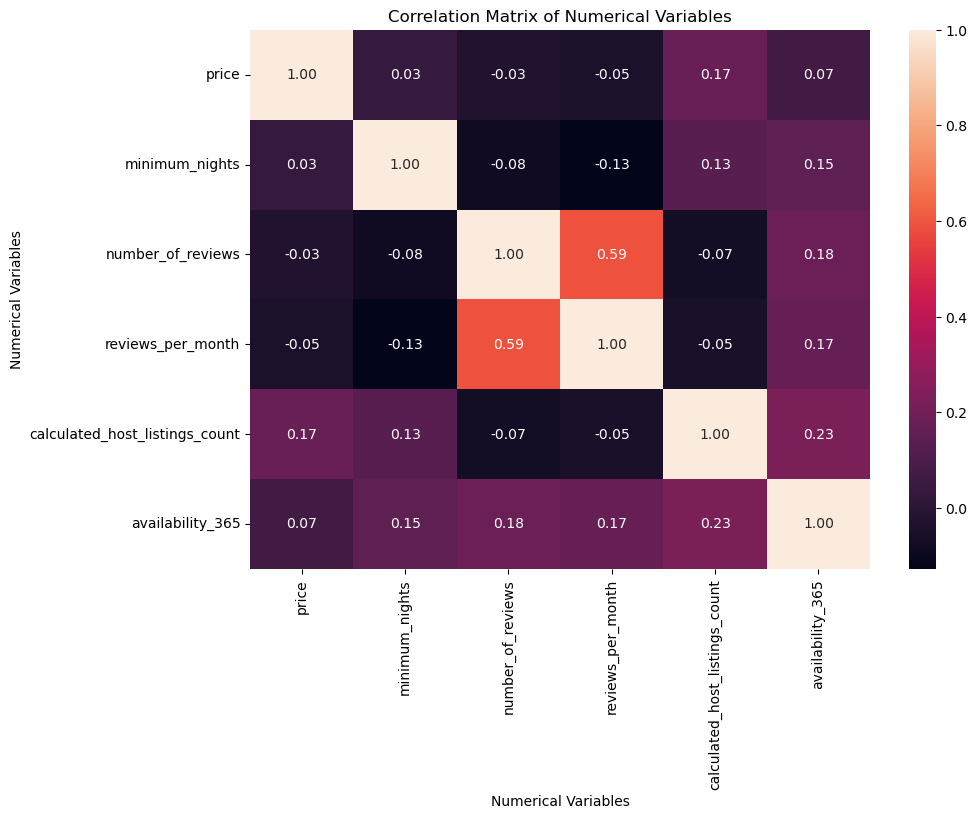

In [201]:
# Multivariate Analysis 2
# Correlation Heatmap

numeric_cols = [
    'price',
    'minimum_nights',
    'number_of_reviews',
    'reviews_per_month',
    'calculated_host_listings_count',
    'availability_365'
]

corr = df_price_clean[numeric_cols].corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f'
)

plt.title('Correlation Matrix of Numerical Variables')
plt.xlabel('Numerical Variables')
plt.ylabel('Numerical Variables')

plt.show()

**Observation:** The correlation matrix shows the strength and direction of relationships among the numerical variables. The correlations with price are generally weak, indicating that these numerical variables do not have strong linear relationships with price.

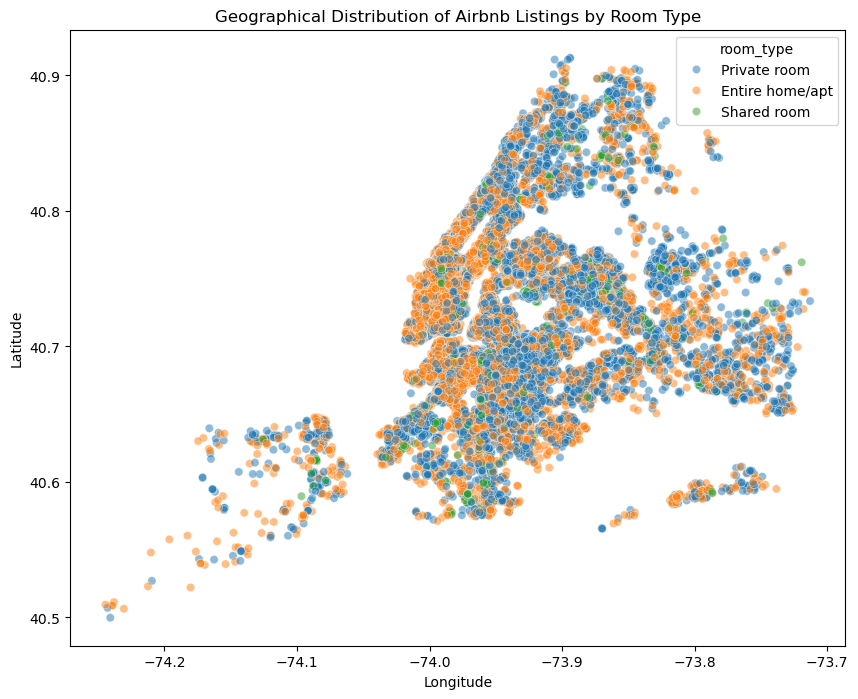

In [202]:
# Multivariate Analysis 3
# Geographical Distribution of Listings by Room Type

plt.figure(figsize=(10, 8))

sns.scatterplot(
    data=df_price_clean,
    x='longitude',
    y='latitude',
    hue='room_type',
    alpha=0.5
)

plt.title('Geographical Distribution of Airbnb Listings by Room Type')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

plt.show()

**Observation:** The geographical scatter plot shows the spatial distribution of Airbnb listings across New York City. Different room types are distributed across different locations, with entire homes/apartments and private rooms forming the majority of listings.

In [61]:
pivot1 = pd.pivot_table(
    df,
    values='price',
    index='neighbourhood_group',
    columns='room_type',
    aggfunc='mean'
)

pivot1

room_type,Entire home/apt,Private room,Shared room
neighbourhood_group,,,
Bronx,127.506596,66.788344,59.800000
Brooklyn,178.327545,76.500099,50.527845
Manhattan,249.239109,116.776622,88.977083
Queens,147.050573,71.762456,69.020202
Staten Island,173.846591,62.292553,57.444444


**Observation**: Average Airbnb price varies across both neighbourhood group and room type. 
Entire homes/apartments generally have higher prices than private and shared rooms across the neighbourhood groups.

In [62]:
pivot2 = pd.pivot_table(
    df,
    values='price',
    index='neighbourhood_group',
    columns='room_type',
    aggfunc='count'
)

pivot2

room_type,Entire home/apt,Private room,Shared room
neighbourhood_group,,,
Bronx,379,652,60
Brooklyn,9559,10132,413
Manhattan,13199,7982,480
Queens,2096,3372,198
Staten Island,176,188,9


**Observation**: Manhattan and Brooklyn have the largest numbers of listings, with entire homes/apartments and private rooms representing most listings.

In [63]:
pivot3 = pd.pivot_table(
    df,
    values='number_of_reviews',
    index='neighbourhood_group',
    columns='room_type',
    aggfunc='mean'
)

pivot3

room_type,Entire home/apt,Private room,Shared room
neighbourhood_group,,,
Bronx,30.678100,25.018405,7.200000
Brooklyn,27.945183,21.086952,14.026634
Manhattan,17.815516,26.202706,21.400000
Queens,28.933206,27.746441,13.863636
Staten Island,33.278409,30.159574,1.555556


**Observation**: Average review counts differ across room types and neighbourhood groups, indicating differences in guest engagement.

In [64]:
pivot4 = pd.pivot_table(
    df,
    values='minimum_nights',
    index='neighbourhood_group',
    columns='room_type',
    aggfunc='mean'
)

pivot4

room_type,Entire home/apt,Private room,Shared room
neighbourhood_group,,,
Bronx,5.957784,3.858896,3.366667
Brooklyn,6.531332,5.539479,7.753027
Manhattan,10.539283,5.446880,6.766667
Queens,5.369752,5.120107,4.232323
Staten Island,6.238636,3.632979,2.333333


**Observation**: Minimum-night requirements vary across neighbourhood groups and room types, indicating different booking policies among hosts.

In [65]:
pivot5 = pd.pivot_table(
    df,
    values='availability_365',
    index='neighbourhood_group',
    columns='room_type',
    aggfunc='mean'
)

pivot5

room_type,Entire home/apt,Private room,Shared room
neighbourhood_group,,,
Bronx,158.000000,171.331288,154.216667
Brooklyn,97.205147,99.917983,178.007264
Manhattan,117.140996,101.845026,138.572917
Queens,132.267176,149.222716,192.186869
Staten Island,178.073864,226.361702,64.777778


**Observation**: Average annual availability differs across room types and neighbourhood groups, suggesting differences in property usage and host availability.

In [188]:
room_counts = df['room_type'].value_counts()

room_percentage = (
    df['room_type']
    .value_counts(normalize=True) * 100
)

pd.DataFrame({
    'count': room_counts,
    'percentage': room_percentage.round(2)
})

,count,percentage
room_type,,
Entire home/apt,25409,51.97
Private room,22326,45.66
Shared room,1160,2.37


**Observation**: Shared rooms represent a much smaller proportion of listings than entire homes/apartments and private rooms. Since this is an EDA project and not a classification model, no resampling technique was applied.

#### Key insights and conclusion

## Key Insights

1. Manhattan and Brooklyn contain the largest number of Airbnb listings.
2. Entire homes/apartments and private rooms account for most listings.
3. Entire homes/apartments generally have higher average prices than private and shared rooms.
4. Airbnb prices are strongly right-skewed, with a relatively small number of high-priced listings.
5. The IQR method identified extreme values in the price variable.
6. Most numerical variables do not show a strong linear relationship with price.
7. Shared rooms represent a much smaller proportion of the listings compared with entire homes/apartments and private rooms.
8. Airbnb listings are distributed across different geographical areas of New York City.

## Conclusion

This exploratory data analysis examined Airbnb listings in New York City to understand pricing, room types, neighbourhood distribution, reviews, minimum-night requirements, and availability.

The analysis showed that listing characteristics and prices vary across neighbourhood groups and room types. Price was found to be right-skewed, with several extreme observations identified using the IQR method. These extreme values were excluded from price-specific analysis while the original dataset was retained.

Univariate, bivariate, and multivariate analyses, along with pivot tables and visualizations, were used to identify important patterns and relationships in the dataset.